In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

In [6]:
totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
totalData.drop(columns=["Unnamed: 0"],inplace=True)

Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    #'ESP Vibration X',
    #'ESP Vibration Y',
    'ESP Vibration Module'
    #'ESP Power',
    #"Well_down"
    ]

/tmp/ipykernel_37371/3682990807.py:1: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


In [7]:
mainSeed = 971215
np.random.seed(mainSeed)

PCAHeaders = [str(i) for i in range(0,7)]

pumpList = totalData["Well Run"].unique()

X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

In [8]:
n = 3

gmmTotal = li.GaussianMixtureFit(totalData[Headers].loc[totalData["Well_down"]==0],n,seed=mainSeed)

modelFull = hmm.GaussianHMM(
    n_components=n,
    random_state=mainSeed,
    covariance_type="full",
    init_params="st",
    algorithm="map"
    )

modelFull.means_ = gmmTotal.means_
modelFull.covars__ = gmmTotal.covariances_


modelFull = li.HMMTrainer(X_train[Headers],trainLength,modelFull)

li.PostProcessing(modelFull, totalData, modelData, Headers, "Full States", totalLength)
print(modelFull.get_stationary_distribution())
totalData["Full States"] = totalData["Full States"].map(li.StateConversion(modelFull.get_stationary_distribution(),n))



GMM BIC: 16641810.76539606
AIC: 16390697.70392595 BIC: 16393062.62567857
[0.41125405 0.48108369 0.10766226]


In [9]:
vibeHeader = ["ESP Vibration X","ESP Vibration Y"]
esotericHeader = ['Water Cut @ 20degC - 1 atm', 'Choke Opening']

n = [3]

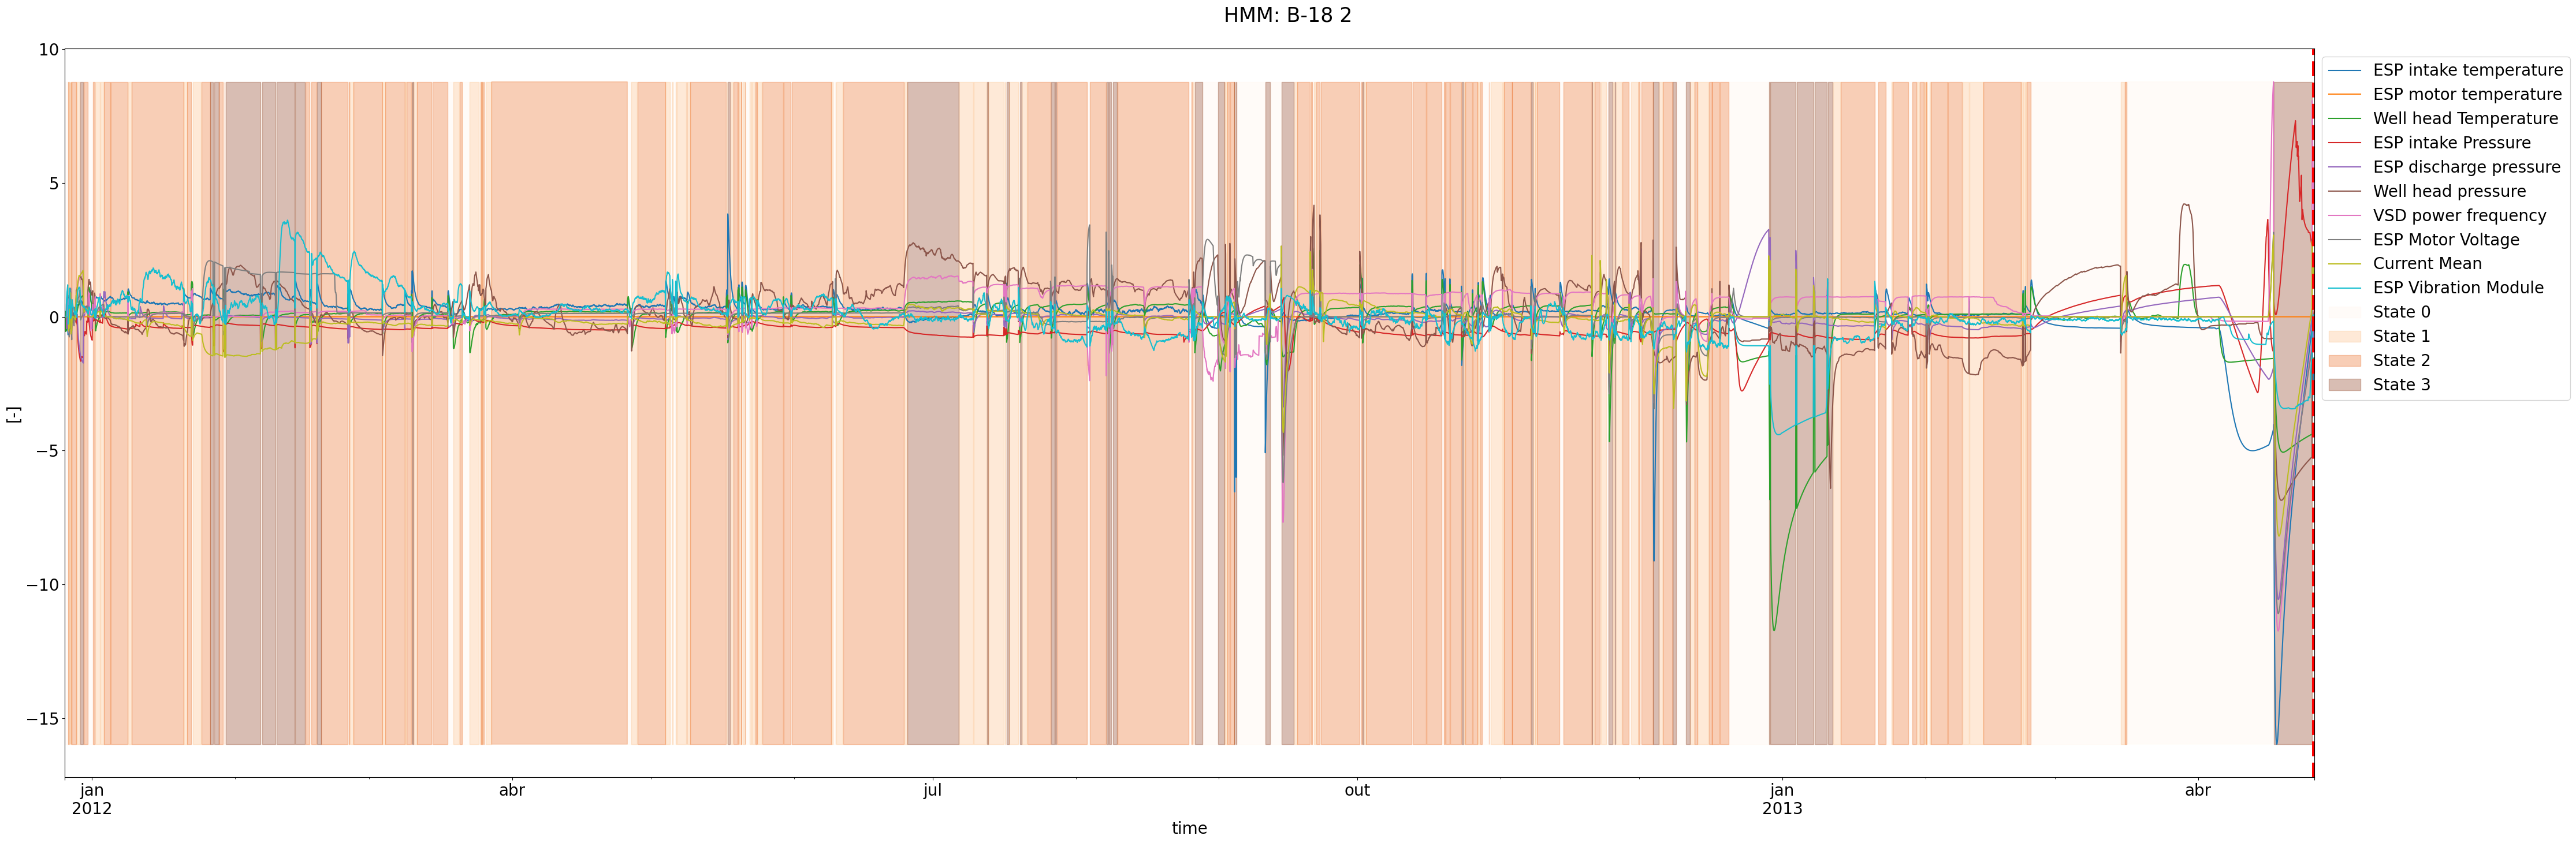

In [11]:
pump = pumpList[0]
pumpData = totalData.loc[totalData["Well Run"]==pump].copy()
fig,axs = li.HMMPicture(pumpData,pump,props=[Headers],measures='[-]',states=["Full States"], numberOfStates=n, figsize=(45,15))
plt.rcParams["font.size"]=20

#fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")


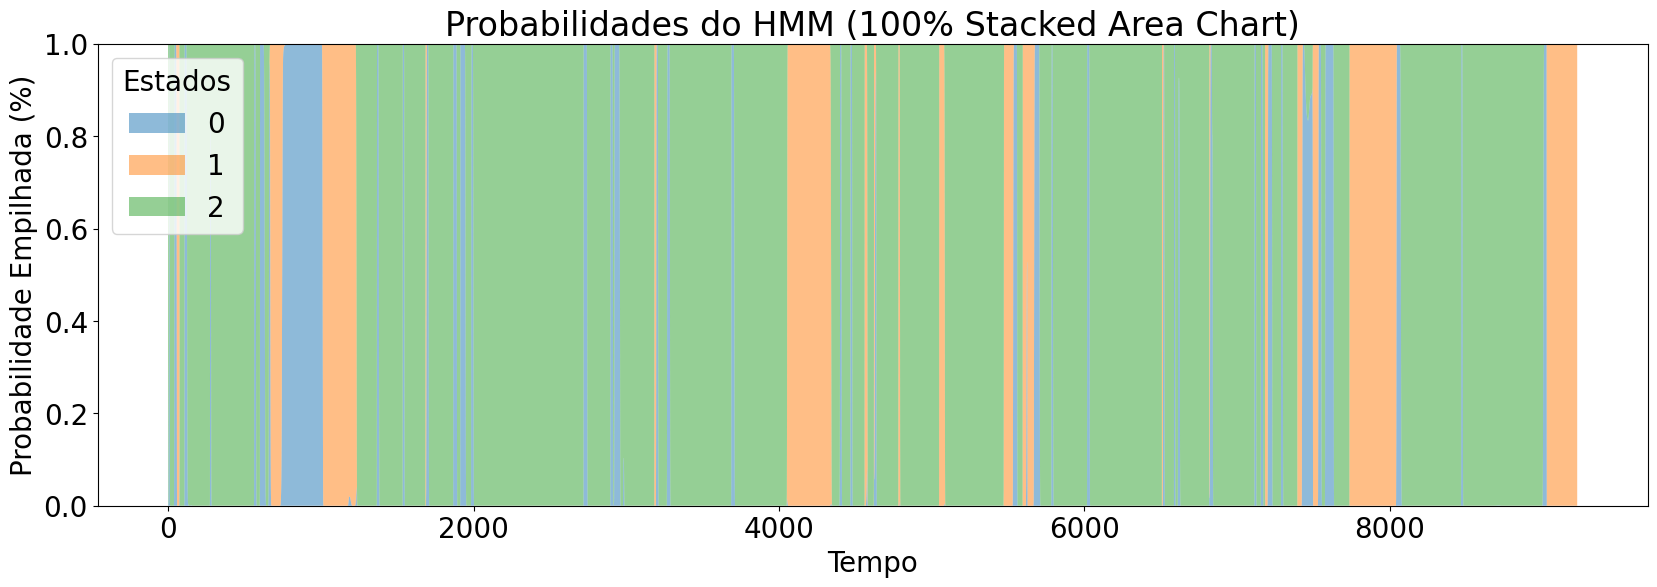

In [12]:
li.PlotHMMProbs(totalData[Headers].loc[(totalData["Well_down"]==0) & (totalData["Well Run"]==pumpList[0])],modelFull)

In [13]:
modelFull.transmat_

array([[9.95137332e-01, 1.01408805e-03, 3.84858012e-03],
       [6.93578265e-03, 9.92188857e-01, 8.75360359e-04],
       [1.63220391e-03, 3.50419918e-04, 9.98017376e-01]])

<Axes: xlabel='time'>

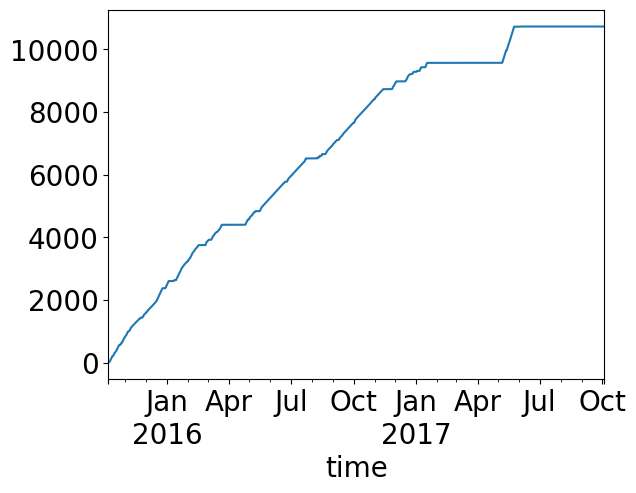

In [14]:
pumpData["Full States"].cumsum().plot()